# Taxi trip price prediction 🚖💵

In [10]:
# Importing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

In [11]:
# Read data
df = pd.read_csv ("../data/taxi_trip_pricing.csv")
df.head ()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [12]:
num_of_actual_rec = df.shape [0]
df.shape

(1000, 11)

In [13]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [14]:
df.describe ()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [15]:
df.duplicated ().sum ()

np.int64(0)

# No duplicated

In [16]:
df.isnull ().sum ()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [17]:
all_col = df.columns

cat_col = df.select_dtypes (include= ["object"]).columns

num_col = df.select_dtypes (include= ["float64"]).columns

# fill Nan for Categorical data

In [18]:
for col in cat_col:
    the_mode = df [col].mode () [0]
    df [col] = df [col].fillna (value= the_mode)

In [19]:
df.isnull ().sum ()

Trip_Distance_km         50
Time_of_Day               0
Day_of_Week               0
Passenger_Count          50
Traffic_Conditions        0
Weather                   0
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

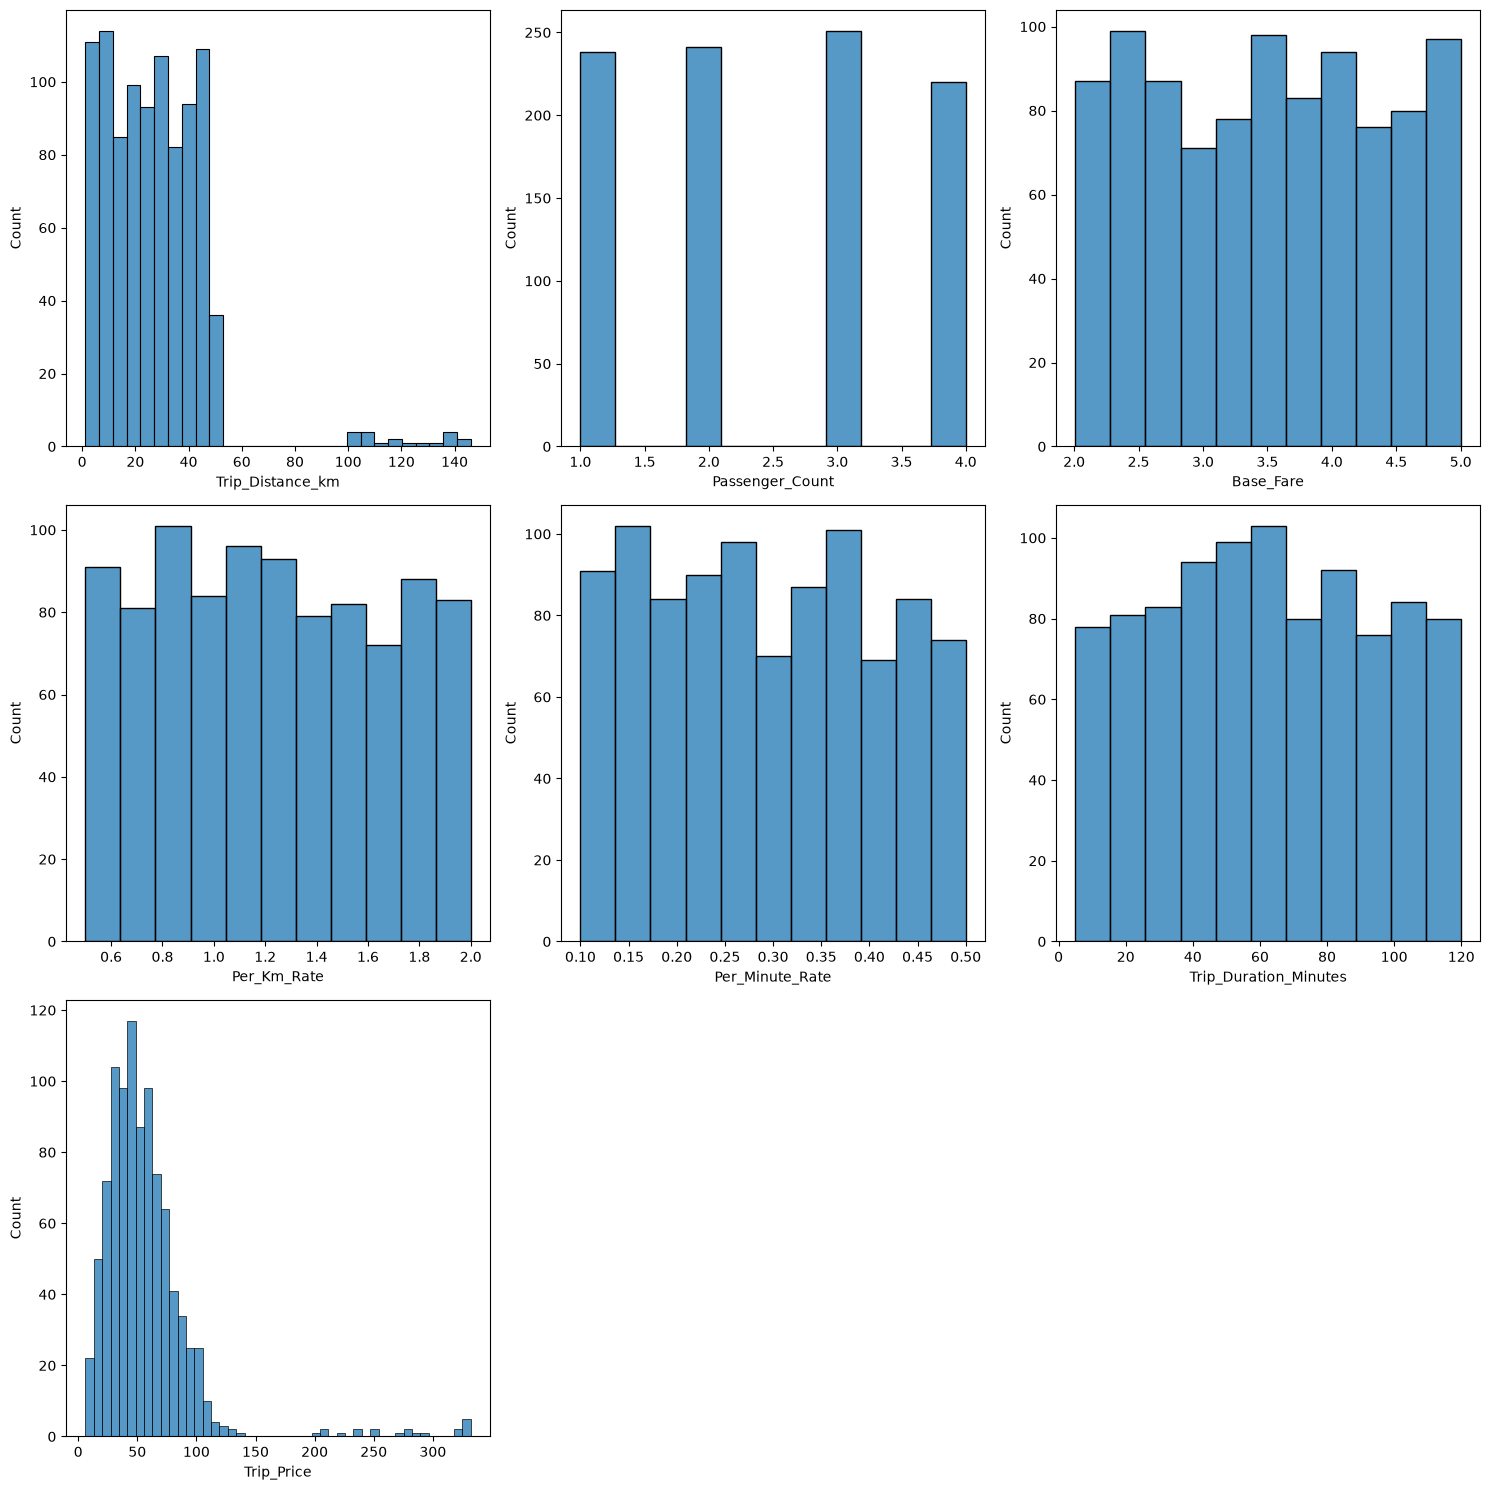

In [20]:
import math

n = len (num_col)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (num_col):
    sns.histplot (df [col], ax= axes [i])
    # axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

# fill Nan for numerical data

In [21]:
columns = df.select_dtypes (include= ["float64"]).columns
for col in columns:
    mean = df [col].mean ()
    median = df [col].median ()

    fill = 0
    taken = ""

    if abs (mean - median) < 1:
        fill = mean
        taken = "mean"
    else:
        fill = median
        taken = "median"

    print (f"{col}: {taken}")

    df [col] = df [col].fillna (value= fill)

Trip_Distance_km: median
Passenger_Count: mean
Base_Fare: mean
Per_Km_Rate: mean
Per_Minute_Rate: mean
Trip_Duration_Minutes: mean
Trip_Price: median


In [22]:
df.isnull ().sum ()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [23]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


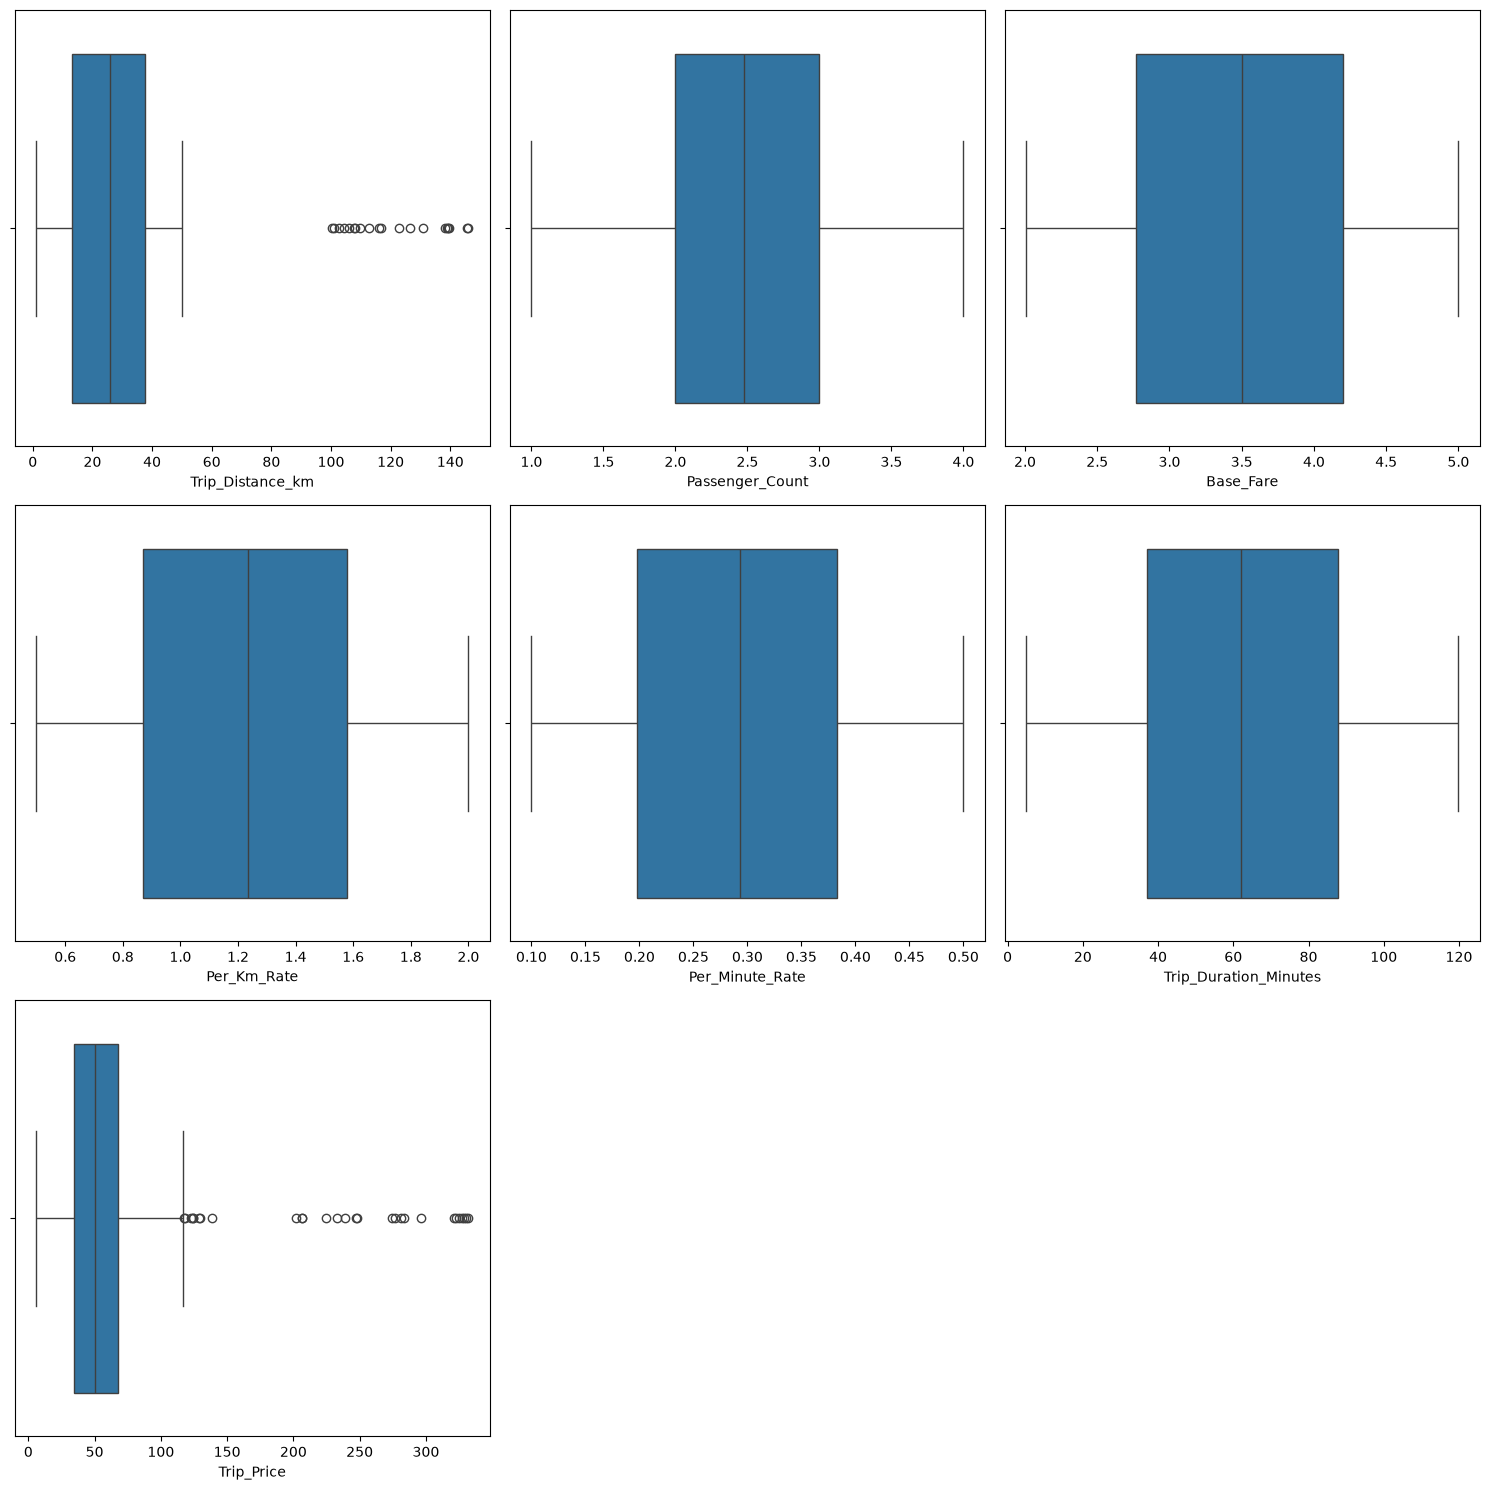

In [24]:
n = len (num_col)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (num_col):
    sns.boxplot (data= df, x= col, ax= axes [i])
    # axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

In [25]:
def calculate_iqr_bounds (series : pd.Series):
    q1 = series.quantile (0.25)
    q3 = series.quantile (0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return iqr, lower_bound, upper_bound

In [26]:
for col in ("Trip_Distance_km", "Trip_Price"):
    iqr, lower_bound, upper_bound = calculate_iqr_bounds (series= df [col])

    df = df [(df [col] > lower_bound) & (df [col] < upper_bound)]

df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,50.0745
2,36.87,Evening,Weekend,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.4698
4,25.83,Evening,Weekday,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.2090


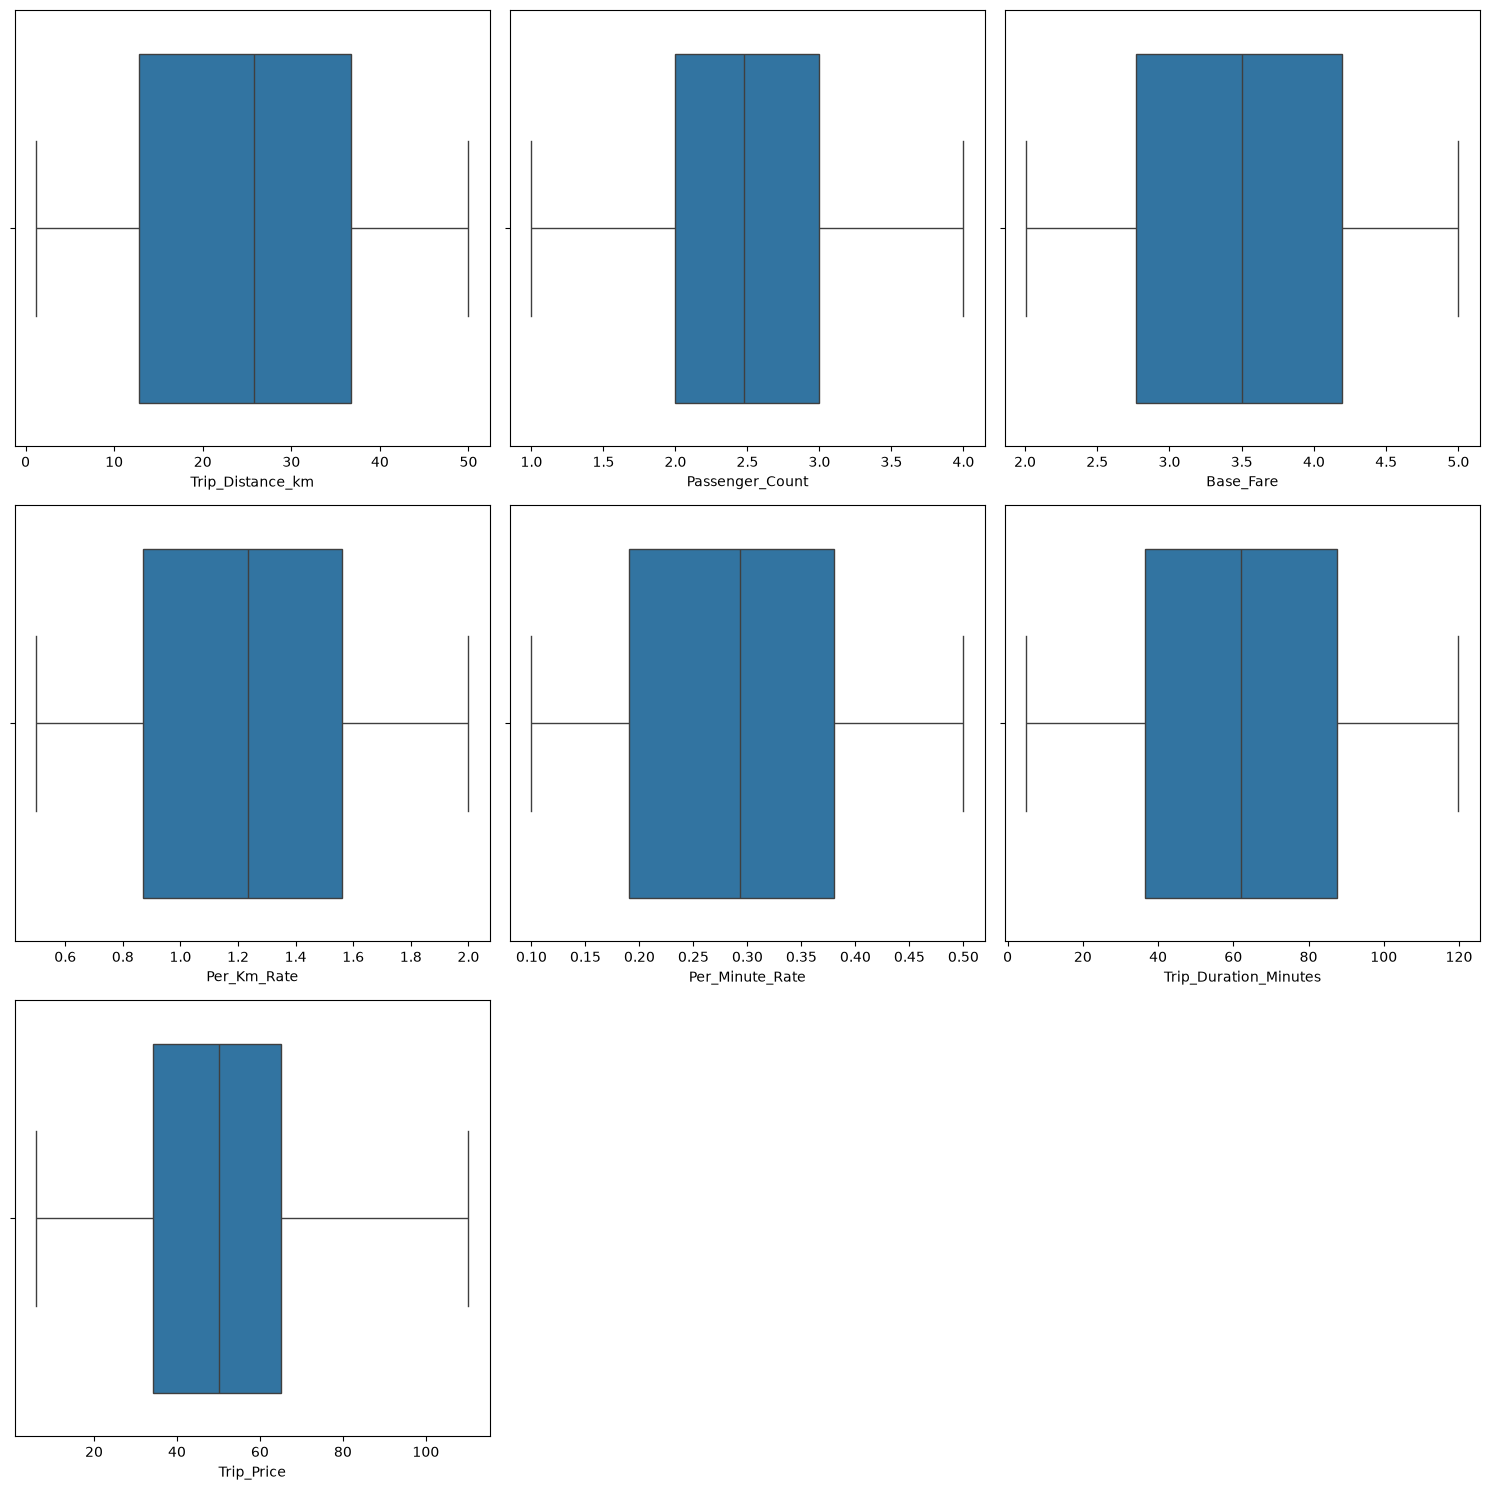

In [27]:
n = len (num_col)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (num_col):
    sns.boxplot (data= df, x= col, ax= axes [i])
    # axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

In [28]:
print (f"Number of Lost rows: {num_of_actual_rec - df.shape [0]}")

Number of Lost rows: 30


In [29]:
correlations = df.drop (columns= cat_col).corr ()
correlations

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.015786,0.039688,-0.060175,-0.024781,-0.047857,0.657954
Passenger_Count,-0.015786,1.000000,0.024199,0.029448,0.030069,0.025017,0.049879
Base_Fare,0.039688,0.024199,1.000000,-0.003387,-0.018746,0.009721,0.036908
Per_Km_Rate,-0.060175,0.029448,-0.003387,1.000000,0.017153,0.013329,0.381789
Per_Minute_Rate,-0.024781,0.030069,-0.018746,0.017153,1.000000,-0.034015,0.246924
Trip_Duration_Minutes,-0.047857,0.025017,0.009721,0.013329,-0.034015,1.000000,0.335585
Trip_Price,0.657954,0.049879,0.036908,0.381789,0.246924,0.335585,1.000000


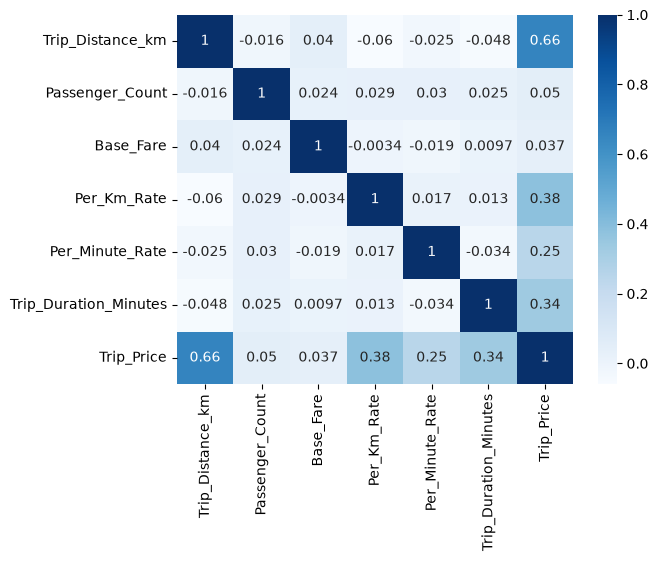

In [30]:
sns.heatmap (data= correlations, annot= True, cmap= "Blues")
plt.show ()

In [31]:
for col in cat_col:
    print (df [col].unique ())
    print ('-' * 50)

['Morning' 'Afternoon' 'Evening' 'Night']
--------------------------------------------------
['Weekday' 'Weekend']
--------------------------------------------------
['Low' 'High' 'Medium']
--------------------------------------------------
['Clear' 'Rain' 'Snow']
--------------------------------------------------


In [32]:
for col in cat_col:
    df_dummy = pd.get_dummies (df [col], dtype= int, drop_first= True)
    df= pd.concat ([df, df_dummy], axis=1)
    df.drop (col, axis=1, inplace=True)

df.head ()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Evening,Morning,Night,Weekend,Low,Medium,Rain,Snow
0,19.35,3.0,3.560000,0.80,0.32,53.82,36.2624,0,1,0,0,1,0,0,0
1,47.59,1.0,3.502989,0.62,0.43,40.57,50.0745,0,0,0,0,0,0,0,0
2,36.87,1.0,2.700000,1.21,0.15,37.27,52.9032,1,0,0,1,0,0,0,0
3,30.33,4.0,3.480000,0.51,0.15,116.81,36.4698,1,0,0,0,1,0,0,0
4,25.83,3.0,2.930000,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0


In [33]:
x = df.drop ("Trip_Price", axis= 1)
y = df ["Trip_Price"]

In [34]:
x_train, x_test, y_train, y_test = train_test_split (
    x, y, test_size= 0.2, random_state=42
)

In [35]:
stand = StandardScaler ()
x_train = stand.fit_transform (x_train)
x_test = stand.transform (x_test)
x_train

array([[ 0.47872598,  0.47477481, -1.45688731, ..., -0.78957644,
        -0.54359221, -0.25102529],
       [ 1.40883366, -0.44987255,  1.73162324, ..., -0.78957644,
        -0.54359221, -0.25102529],
       [ 0.02594841,  1.39942217,  0.10773497, ...,  1.26650181,
         1.8396143 , -0.25102529],
       ...,
       [ 0.82534996,  1.39942217, -1.45688731, ..., -0.78957644,
        -0.54359221, -0.25102529],
       [-0.22896464, -0.44987255,  1.04413769, ..., -0.78957644,
        -0.54359221, -0.25102529],
       [-0.84783287, -0.44987255,  0.35665215, ..., -0.78957644,
         1.8396143 , -0.25102529]], shape=(776, 14))

In [36]:
model = LinearRegression ()

In [37]:
model.fit (x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[15.61, 0.73, 0.3 ,...,-0.26,-0.02, 0.18]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,51.59
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[36.64,32.76,31.14,...,24.97,20.14,15.05]"


In [38]:
y_pred = model.predict (x_test)

In [39]:
mae = mean_absolute_error (y_test , y_pred)
mse = mean_squared_error (y_test , y_pred)
rmse = np.sqrt (mean_squared_error (y_test , y_pred))
r2 = r2_score (y_test , y_pred)

In [40]:
print ("R2:", r2)
print ("MAE:", mae)
print ("MSE:", mse)
print ("RMSE:", rmse)

R2: 0.8294495401071535
MAE: 7.10109814829928
MSE: 85.16182109404645
RMSE: 9.228316265389177


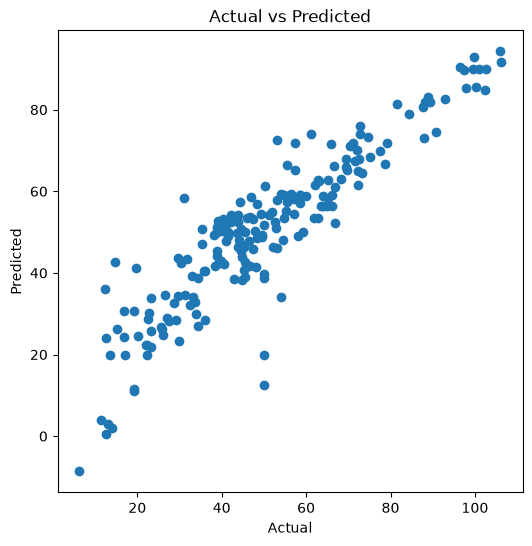

In [41]:
plt.figure (figsize= (6,6))
plt.scatter (y_test, y_pred)
plt.xlabel ("Actual")
plt.ylabel ("Predicted")
plt.title ("Actual vs Predicted")
plt.show ()